1. Завантаження датасету

In [ ]:
!rm SpamEmailClassificationDataset.zip*

rm: cannot remove 'SpamEmailClassificationDataset.zip*': No such file or directory


In [ ]:
!wget -O SpamEmailClassificationDataset.zip \
https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/main/SpamEmailClassificationDataset.zip

--2026-03-15 17:20:17--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/main/SpamEmailClassificationDataset.zip
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/main/SpamEmailClassificationDataset.zip [following]
--2026-03-15 17:20:18--  https://raw.githubusercontent.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/main/SpamEmailClassificationDataset.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7577397 (7.2M) [application/zip]
Saving to: ‘SpamEmailClassificationDataset.zip’

SpamEmailClassifica 100%[===================>]   7.23

In [ ]:
!unzip -o SpamEmailClassificationDataset.zip

Archive:  SpamEmailClassificationDataset.zip
   creating: SpamEmailClassificationDataset/
  inflating: SpamEmailClassificationDataset/combined_data.csv  


In [ ]:
!ls

sample_data  SpamEmailClassificationDataset  SpamEmailClassificationDataset.zip


In [ ]:
import pandas as pd

df = pd.read_csv('./SpamEmailClassificationDataset/combined_data.csv')

2. Первинний аналіз даних

In [ ]:
print("Назви колонок:")
print(df.columns.tolist())

print("\nПерші 5 рядків:")
display(df.head())

print("\nРозмір датасету:")
print(df.shape)

Назви колонок:
['label', 'text']

Перші 5 рядків:


,label,text
0,label,text
1,1,ounce feather bowl hummingbird opec moment ala...
2,1,wulvob get your medircations online qnb ikud v...
3,0,computer connection from cnn com wednesday es...
4,1,university degree obtain a prosperous future m...



Розмір датасету:
(14861, 2)


In [ ]:
print(df['label'].value_counts())
print(df['label'].unique())

label
1        7813
0        7047
label       1
Name: count, dtype: int64


3. Формування підвибірки для аналізу

In [ ]:
spam_df = df[df['label'] == '1'].sample(n=1000, random_state=42)
ham_df = df[df['label'] == '0'].sample(n=1000, random_state=42)

df_balanced = pd.concat([spam_df, ham_df], axis=0)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

#df_balanced.shape
df_balanced['label'].value_counts()


,count
label,
0,1000
1,1000


4. Візуалізація розподілу класів

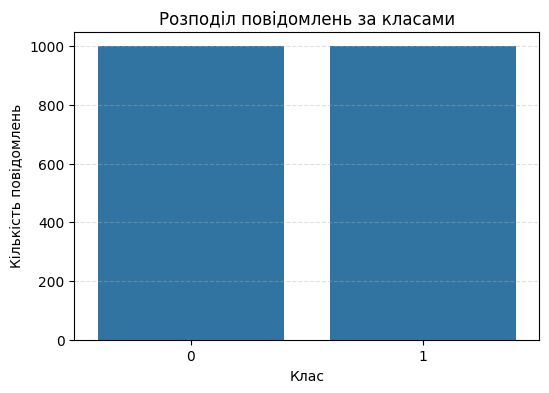

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(data=df_balanced, x='label')
plt.title('Розподіл повідомлень за класами')
plt.xlabel('Клас')
plt.ylabel('Кількість повідомлень')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

5. Попередня обробка тексту

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
import re

def preprocess_text(text):
    text = str(text)
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    words = list(set(words))   # видалення повторів слів у межах одного повідомлення
    return " ".join(words)

In [ ]:
df_balanced['text'] = df_balanced['text'].apply(preprocess_text)

In [ ]:
df_balanced.head()

,label,text
0,0,registration using retracting morning rientati...
1,1,ratas fue borrarsp nica nelo lagos nuevamente ...
2,0,unfortunately gng guide one using flxglm pleas...
3,1,certified break meridiaas raise low best make ...
4,0,represent culture back sure call please look m...


In [ ]:
# видалити порожні тексти після очищення
df_balanced = df_balanced[df_balanced['text'].str.strip() != ""].reset_index(drop=True)
df_balanced.shape

(1999, 2)

6. Поділ на train і test без sklearn

In [ ]:
import numpy as np

np.random.seed(42)

indices = np.random.permutation(len(df_balanced))
split_index = int(0.8 * len(df_balanced))

train_indices = indices[:split_index]
test_indices = indices[split_index:]

train_df = df_balanced.iloc[train_indices].reset_index(drop=True)
test_df = df_balanced.iloc[test_indices].reset_index(drop=True)

In [ ]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1599, 2)
Test shape: (400, 2)


In [67]:
print('Train:')
print(train_df['label'].value_counts())
print('\nTest:')
print(test_df['label'].value_counts())

Train:
label
0    800
1    799
Name: count, dtype: int64

Test:
label
0    200
1    200
Name: count, dtype: int64


7. Формування структур train_spam, train_ham, test_emails

In [ ]:
train_spam = train_df[train_df['label'] == '1']['text'].tolist() # spam
train_ham = train_df[train_df['label'] == '0']['text'].tolist()  # ham

In [ ]:
test_emails = {
    i: {
        'text': row['text'],
        'label': row['label']
    }
    for i, row in test_df.iterrows()
}

In [ ]:
print("Кількість spam для train:", len(train_spam))
print("Кількість ham для train:", len(train_ham))
print("Кількість test повідомлень:", len(test_emails))

Кількість spam для train: 799
Кількість ham для train: 800
Кількість test повідомлень: 400


8. Побудова словника слів

In [ ]:
spam_words = [word.lower() for email in train_spam for word in email.split()]
ham_words = [word.lower() for email in train_ham for word in email.split()]

In [ ]:
vocabulary = sorted(list(set(spam_words) | set(ham_words)))
print("Кількість унікальних слів у словнику:", len(vocabulary))

Кількість унікальних слів у словнику: 28655


9. Підрахунок, у скількох листах зустрічається слово

In [ ]:
# Рахуємо, у скількох листах зустрічається слово
from collections import defaultdict

spam_word_counts = defaultdict(int)
ham_word_counts = defaultdict(int)

# рахуємо слова у spam
for email in train_spam:
    words = set(email.split())
    for word in words:
        spam_word_counts[word] += 1

# рахуємо слова у ham
for email in train_ham:
    words = set(email.split())
    for word in words:
        ham_word_counts[word] += 1

In [ ]:
# Обчислюємо spamicity та hamicity зі згладжуванням Лапласа
dict_spamicity = {}
dict_hamicity = {}

total_spam = len(train_spam)
total_ham = len(train_ham)

for word in vocabulary:

    spam_count = spam_word_counts[word]
    ham_count = ham_word_counts[word]

    dict_spamicity[word] = (spam_count + 1) / (total_spam + 2)
    dict_hamicity[word] = (ham_count + 1) / (total_ham + 2)

In [ ]:
print("Словник spamicity:")
list(dict_spamicity.items())[:10]

Словник spamicity:


[('aa', 0.003745318352059925),
 ('aaa', 0.0024968789013732834),
 ('aaaaa', 0.0012484394506866417),
 ('aac', 0.004993757802746567),
 ('aacs', 0.0012484394506866417),
 ('aaes', 0.0024968789013732834),
 ('aamlahu', 0.0024968789013732834),
 ('aanopsm', 0.0024968789013732834),
 ('aarhus', 0.0024968789013732834),
 ('aaron', 0.0024968789013732834)]

In [ ]:
print("Словник hamicity:")
list(dict_hamicity.items())[:10]

Словник hamicity:


[('aa', 0.007481296758104738),
 ('aaa', 0.004987531172069825),
 ('aaaaa', 0.0024937655860349127),
 ('aac', 0.0012468827930174563),
 ('aacs', 0.0024937655860349127),
 ('aaes', 0.0012468827930174563),
 ('aamlahu', 0.0012468827930174563),
 ('aanopsm', 0.0012468827930174563),
 ('aarhus', 0.0012468827930174563),
 ('aaron', 0.003740648379052369)]

10. Апріорні ймовірності класів

In [ ]:
# Апріорні ймовірності класів
prob_spam = len(train_spam) / (len(train_spam) + len(train_ham))
prob_ham = len(train_ham) / (len(train_spam) + len(train_ham))

print(f"Ймовірність спаму, P(spam) = {prob_spam:.4f}")
print(f"Ймовірність важливого повідомлення, P(ham) = {prob_ham:.4f}")

Ймовірність спаму, P(spam) = 0.4997
Ймовірність важливого повідомлення, P(ham) = 0.5003


11. Функція класифікації повідомлення

In [ ]:
def classify_email(text, dict_spamicity, dict_hamicity, prob_spam, prob_ham, total_spam, total_ham):
    #words = text.split() # Multinomial Naive Bayes, потребує змін в spamicity, spam часто містить повтори
    words = set(text.split()) # Bernoulli Naive Bayes

    log_spam_score = np.log(prob_spam) # log(P(spam))
    log_ham_score = np.log(prob_ham) # log(P(ham))

    # Laplace smoothing
    default_spam_prob = 1 / (total_spam + 2)
    default_ham_prob = 1 / (total_ham + 2)

    # це логарифмічні оцінки ймовірностей належності листа до відповідних класів.
    # log_spam_score +≈ Σ log(P(word | spam))
    # log_ham_score  +≈ Σ log(P(word | ham))
    for word in words:
        log_spam_score += np.log(dict_spamicity.get(word, default_spam_prob))
        log_ham_score += np.log(dict_hamicity.get(word, default_ham_prob))

    predicted_label = 'spam' if log_spam_score > log_ham_score else 'ham'
    return predicted_label, log_spam_score, log_ham_score

12. Перевірка на одному тестовому прикладі

In [ ]:
sample_text = test_df.loc[0, 'text']
sample_true_label = test_df.loc[0, 'label']

pred_label, spam_score, ham_score = classify_email(
    sample_text,
    dict_spamicity,
    dict_hamicity,
    prob_spam,
    prob_ham,
    total_spam,
    total_ham
)

print("Текст:", sample_text)
print("Справжній клас:", 'spam' if sample_true_label == '1' else 'ham')
print("Прогноз:", pred_label)
print("log spam score:", spam_score)
print("log ham score:", ham_score)

Текст: correct back see help org validate definition f script beginner block execute joseph continuing write perl order know sort perldoc escapenumber want die following reverse mail unsubscribe croak skip way carp far command without wrote learn sub defined e return end execution done additional entire read clearly snip conditional http casale reading cannot l understanding exit
Справжній клас: ham
Прогноз: ham
log spam score: -236.50200967579516
log ham score: -183.57029464193758


13. Тестування на всій вибірці

In [ ]:
y_true = []
y_pred = []

for _, item in test_emails.items():
    true_label = 'spam' if item['label'] == '1' else 'ham'
    pred_label, _, _ = classify_email(
        item['text'],
        dict_spamicity,
        dict_hamicity,
        prob_spam,
        prob_ham,
        total_spam,
        total_ham
    )

    y_true.append(true_label)
    y_pred.append(pred_label)

14. Обчислення точності класифікатора - Accuracy

In [ ]:
accuracy = np.mean(np.array(y_true) == np.array(y_pred))
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.8575


15. Додатково: матриця помилок вручну

In [ ]:
tp = sum((yt == 'spam') and (yp == 'spam') for yt, yp in zip(y_true, y_pred))
tn = sum((yt == 'ham') and (yp == 'ham') for yt, yp in zip(y_true, y_pred))
fp = sum((yt == 'ham') and (yp == 'spam') for yt, yp in zip(y_true, y_pred))
fn = sum((yt == 'spam') and (yp == 'ham') for yt, yp in zip(y_true, y_pred))

print("TP =", tp)
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)

TP = 143
TN = 200
FP = 0
FN = 57


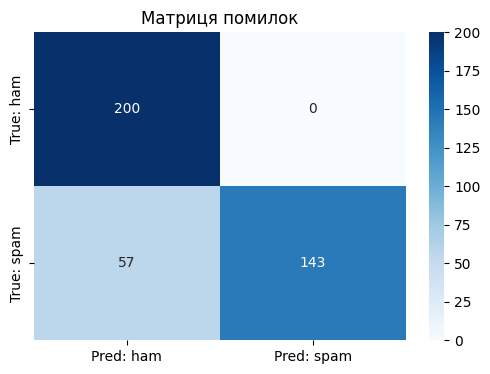

In [ ]:
conf_matrix = np.array([[tn, fp],
                        [fn, tp]])

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: ham', 'Pred: spam'],
            yticklabels=['True: ham', 'True: spam'])
plt.title('Матриця помилок')
plt.show()

16. Аналіз слів, які найімовірніше зустрічаються у spam

In [ ]:
top_spam_words = sorted(dict_spamicity.items(), key=lambda x: x[1], reverse=True)[:20]
top_spam_words

[('escapenumber', 0.48314606741573035),
 ('http', 0.40574282147315854),
 ('com', 0.3096129837702871),
 ('one', 0.2858926342072409),
 ('price', 0.26591760299625467),
 ('u', 0.26217228464419473),
 ('time', 0.22846441947565543),
 ('day', 0.21223470661672908),
 ('get', 0.19101123595505617),
 ('please', 0.1797752808988764),
 ('www', 0.1735330836454432),
 ('escapelong', 0.17228464419475656),
 ('offer', 0.17103620474406991),
 ('new', 0.1647940074906367),
 ('best', 0.16354556803995007),
 ('see', 0.16229712858926343),
 ('money', 0.15980024968789014),
 ('like', 0.15730337078651685),
 ('product', 0.15480649188514356),
 ('information', 0.1523096129837703)]

In [ ]:
top_spam_df = pd.DataFrame(top_spam_words, columns=['word', 'P(word|spam)'])
top_spam_df

,word,P(word|spam)
0,escapenumber,0.483146
1,http,0.405743
2,com,0.309613
3,one,0.285893
4,price,0.265918
5,u,0.262172
6,time,0.228464
7,day,0.212235
8,get,0.191011
9,please,0.179775


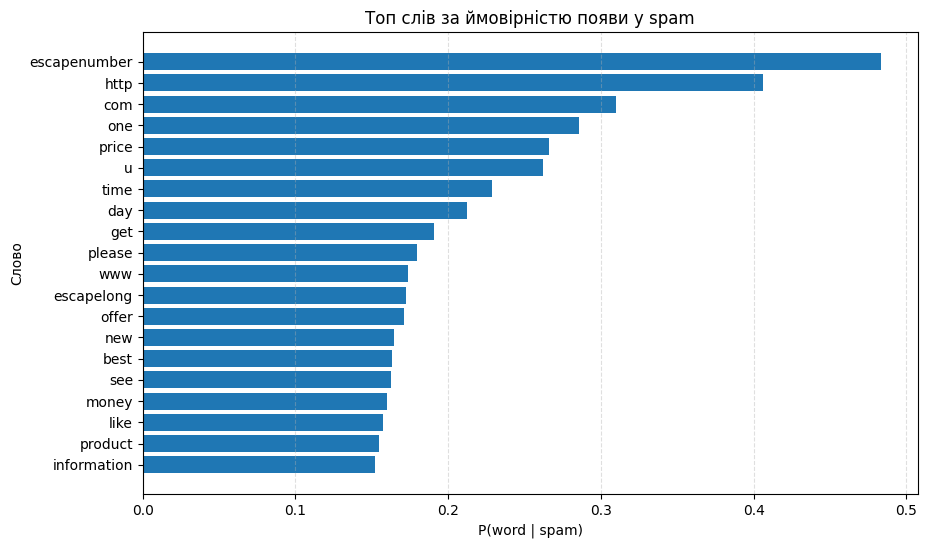

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top_spam_df['word'][::-1], top_spam_df['P(word|spam)'][::-1])
plt.title('Топ слів за ймовірністю появи у spam')
plt.xlabel('P(word | spam)')
plt.ylabel('Слово')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()

17. Аналіз слів, які сильніше відрізняють spam від ham

In [ ]:
spam_importance = []

for word in vocabulary:
    ratio = dict_spamicity[word] / dict_hamicity[word]
    spam_importance.append((word, ratio, dict_spamicity[word], dict_hamicity[word]))

spam_importance = sorted(spam_importance, key=lambda x: x[1], reverse=True)[:20]
spam_importance[:10]

[('cialis', 39.04868913857678, 0.04868913857677903, 0.0012468827930174563),
 ('viagra', 37.04619225967541, 0.046192259675405745, 0.0012468827930174563),
 ('canadianpharmacy',
  35.04369538077403,
  0.04369538077403246,
  0.0012468827930174563),
 ('hk', 35.04369538077403, 0.08739076154806492, 0.0024937655860349127),
 ('acrobat', 34.04244694132335, 0.04244694132334582, 0.0012468827930174563),
 ('photoshop', 32.03995006242197, 0.039950062421972535, 0.0012468827930174563),
 ('autodesk', 29.036204744069913, 0.03620474406991261, 0.0012468827930174563),
 ('illustrator',
  27.03370786516854,
  0.033707865168539325,
  0.0012468827930174563),
 ('spescapenumber',
  27.03370786516854,
  0.033707865168539325,
  0.0012468827930174563),
 ('autocad', 26.032459425717857, 0.03245942571785269, 0.0012468827930174563)]

In [ ]:
spam_importance_df = pd.DataFrame(
    spam_importance,
    columns=['word', 'spam/ham ratio', 'P(word|spam)', 'P(word|ham)']
)

spam_importance_df

,word,spam/ham ratio,P(word|spam),P(word|ham)
0,cialis,39.048689,0.048689,0.001247
1,viagra,37.046192,0.046192,0.001247
2,canadianpharmacy,35.043695,0.043695,0.001247
3,hk,35.043695,0.087391,0.002494
4,acrobat,34.042447,0.042447,0.001247
5,photoshop,32.039950,0.039950,0.001247
6,autodesk,29.036205,0.036205,0.001247
7,illustrator,27.033708,0.033708,0.001247
8,spescapenumber,27.033708,0.033708,0.001247
9,autocad,26.032459,0.032459,0.001247


**Висновок**

У ході виконання роботи було завантажено та підготовлено датасет електронних повідомлень для задачі класифікації spam та ham листів. Для подальшого аналізу сформовано вибірку повідомлень двох класів. Перед побудовою моделі було виконано попередню обробку текстів: переведення символів до нижнього регістру, видалення небуквених символів, усунення стоп-слів, лематизацію слів та видалення повторів у межах одного повідомлення. Видалення повторів є допустимим, оскільки в даній реалізації класифікатора враховується лише факт наявності слова у повідомленні, а не кількість його повторень.

Далі було реалізовано класифікатор на основі наївного Баєса. Для кожного слова зі словника було обчислено ймовірності його появи у spam та ham повідомленнях із використанням Laplace-згладжування. Під час обчислення використовувались логарифми ймовірностей, що дозволяє уникнути проблем числової нестабільності, які виникають при множенні великої кількості дуже малих значень.

Після навчання модель було перевірено на тестовій вибірці. За результатами тестування отримано точність класифікації Accuracy = 0.8575, що свідчить про достатньо хорошу якість роботи моделі. Аналіз матриці помилок показав, що класифікатор правильно визначив 143 spam-повідомлення (TP) та 200 звичайних листів (TN). При цьому помилкових спрацьовувань (FP) не було, а 57 spam-повідомлень були помилково класифіковані як ham (FN).

Отримані результати демонструють, що метод наївного Баєса є простим у реалізації та ефективним підходом для задачі текстової класифікації. Незважаючи на відносну простоту моделі, вона здатна забезпечити високу точність визначення spam-повідомлень і може використовуватися як базовий метод для побудови систем автоматичної фільтрації електронної пошти.